# 2.1 — Modelo de un periodo

## Motivación

El modelo de un periodo con dos estados (binomial de un paso) es el objeto matemático más simple donde ya aparecen, en su forma completa, las tres ideas que sostienen toda la teoría de pricing de derivados: (i) el **portafolio replicante** — un derivado se puede fijar sin conocer las probabilidades reales del mundo físico, construyendo una cartera de subyacente y bono que reproduce su payoff en todo estado; (ii) **no-arbitraje** — la ausencia de estrategias que generen ganancia sin riesgo restringe los parámetros del modelo a una condición precisa, `d < e^{rT} < u`; y (iii) la **medida neutral al riesgo** $\mathbb{Q}$ — bajo la cual el precio de cualquier derivado es la esperanza descontada de su payoff, $V_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[V_T]$. Estas tres ideas, derivadas aquí sin cálculo estocástico, son exactamente las que reaparecen en el árbol CRR multi-periodo (2.2), en los teoremas fundamentales del asset pricing (2.3) y, en el límite continuo, en Black-Scholes (3.1).

El modelo también expone su propia frontera: con solo dos activos ($S$ y el bono) y dos estados del mundo, el mercado es **completo** — todo derivado es replicable y tiene un precio único. En cuanto añadimos un tercer estado posible (el mercado **trinomial**) el sistema de replicación queda sobredeterminado: ya no existe, en general, una cartera que replique exactamente todo payoff, y $\mathbb{Q}$ deja de ser única. Lo que sobrevive es un **intervalo** de precios libres de arbitraje, delimitado por los problemas de super-replicación y sub-replicación — dos programas lineales pequeños que resolvemos con `scipy.optimize.linprog`. Esta incompletitud es el prototipo discreto de lo que ocurre en mercados reales con saltos, volatilidad estocástica o costos de transacción, donde el pricing por réplica exacta deja de ser posible y hay que recurrir a acotamientos o a criterios de selección de medida (superhedging, minimización de varianza, etc.).

Cubrimos: (i) el modelo binomial de un periodo — portafolio replicante, derivación completa; (ii) no-arbitraje $\iff d < e^{rT} < u \iff \exists\, q \in (0,1)$, y precio como esperanza descontada bajo $\mathbb{Q}$; (iii) completitud del modelo binomial; (iv) el modelo trinomial — incompletitud y el intervalo de precios sin arbitraje vía programación lineal.

## 1. El modelo binomial de un periodo

### 1.1 Configuración

Consideramos un mercado con dos instantes, $t=0$ y $t=T$, dos activos y dos estados posibles del mundo:

- **Activo riesgoso** $S$: hoy vale $S_0$; en $T$ toma uno de dos valores,
$$
S_T(\omega_u) = u\,S_0 \quad \text{(estado "up")}, \qquad S_T(\omega_d) = d\,S_0 \quad \text{(estado "down")}, \qquad 0 < d < u.
$$
- **Activo libre de riesgo** (bono/cuenta de mercado de dinero): $B_0 = 1$, $B_T = e^{rT}$, con $r$ la tasa libre de riesgo continuamente compuesta.

El espacio muestral es $\Omega = \{\omega_u, \omega_d\}$. Un **derivado** con vencimiento $T$ se define por su payoff $V_T: \Omega \to \mathbb{R}$, es decir por el par $(V_T(\omega_u), V_T(\omega_d)) =: (V_u, V_d)$. Para un **call europeo** con strike $K$: $V_u = \max(uS_0 - K, 0)$, $V_d = \max(dS_0-K,0)$.

### 1.2 El portafolio replicante

**Objetivo.** Encontrar $(\Delta, \beta) \in \mathbb{R}^2$ — número de unidades de $S$ y de unidades del bono — tales que el portafolio $\Pi_t = \Delta S_t + \beta B_t$ replique el payoff del derivado en **ambos** estados:
$$
\Delta\, u S_0 + \beta\, e^{rT} = V_u, \qquad \Delta\, d S_0 + \beta\, e^{rT} = V_d.
$$

Este es un sistema lineal $2\times 2$ en $(\Delta,\beta)$. Restando la segunda ecuación de la primera se elimina $\beta$:
$$
\Delta\, S_0 (u - d) = V_u - V_d \quad\implies\quad \Delta = \frac{V_u - V_d}{S_0(u-d)}.
$$
$\Delta$ es la razón entre la dispersión del payoff y la dispersión del subyacente entre los dos estados — el análogo discreto exacto de la griega delta ($\partial V/\partial S$) que se derivará en 3.2. Sustituyendo en la primera ecuación y despejando $\beta$:
$$
\beta = e^{-rT}\left(V_u - \Delta\, u S_0\right) = e^{-rT}\,\frac{u\,V_d - d\,V_u}{u - d}.
$$

**Precio de no-arbitraje.** Si un mercado sin fricciones no admite arbitraje, el único precio consistente para el derivado en $t=0$ es el costo de construir la cartera replicante — de lo contrario, comprar el más barato de {derivado, cartera replicante} y vender el más caro produce una ganancia sin riesgo ni capital inicial (ver §2.2). Por lo tanto
$$
V_0 = \Delta\, S_0 + \beta = \frac{V_u - V_d}{u-d} + e^{-rT}\,\frac{u\,V_d - d\,V_u}{u-d}.
$$

Agrupando términos en $V_u$ y $V_d$:
$$
V_0 = e^{-rT}\left[\underbrace{\frac{e^{rT}-d}{u-d}}_{=:\,q}\, V_u + \underbrace{\frac{u-e^{rT}}{u-d}}_{=\,1-q}\, V_d\right].
$$

Este reagrupamiento es la primera aparición de la medida neutral al riesgo $\mathbb{Q}$ (§2): el precio es $e^{-rT}$ veces un promedio ponderado de $V_u$ y $V_d$ con pesos $q$ y $1-q$ que **no dependen del derivado** — son los mismos para cualquier payoff, solo dependen de $(u,d,r,T)$.

## 2. No-arbitraje y la medida neutral al riesgo

### 2.1 Definición de arbitraje

Una **estrategia de arbitraje** es un portafolio autofinanciado con valor inicial $\Pi_0 \leq 0$, valor final $\Pi_T \geq 0$ en todo estado, y $\Pi_T > 0$ con probabilidad positiva en al menos un estado (o, en la formulación equivalente más fuerte que usamos aquí: $\Pi_0 = 0$ y $\Pi_T \geq 0$ con desigualdad estricta en algún estado). Un mercado **libre de arbitraje** no admite tales estrategias.

### 2.2 Teorema: no-arbitraje $\iff d < e^{rT} < u$

**Proposición.** El modelo binomial de un periodo está libre de arbitraje si y solo si
$$
d < e^{rT} < u.
$$

*Demostración ($\Rightarrow$, por contrapositiva).* Supongamos $e^{rT} \leq d$ (el caso $e^{rT}\geq u$ es simétrico). Construimos un arbitraje: en $t=0$ pedimos prestado $S_0$ al bono ($\beta = -S_0$) y compramos una unidad de $S$ ($\Delta=1$); el costo neto es $\Pi_0 = S_0 - S_0 = 0$. En $T$, el portafolio vale $\Pi_T = S_T - S_0 e^{rT}$. En el estado down, $\Pi_T = dS_0 - S_0 e^{rT} = S_0(d - e^{rT}) \geq 0$ (por hipótesis); en el estado up, $\Pi_T = S_0(u - e^{rT}) > S_0(d-e^{rT}) \geq 0$ ya que $u>d$. Luego $\Pi_T \geq 0$ en ambos estados y $\Pi_T>0$ en al menos uno: arbitraje. Análogamente, si $e^{rT}\geq u$, vender en corto $S$ e invertir el producto en el bono produce un arbitraje simétrico. Por lo tanto, si el mercado está libre de arbitraje, $d<e^{rT}<u$.

*Demostración ($\Leftarrow$).* Supongamos $d<e^{rT}<u$ y sea $\Pi_0=0$ para un portafolio $(\Delta,\beta)$ arbitrario con $\beta = -\Delta S_0$ (autofinanciado con capital inicial nulo). Entonces $\Pi_T = \Delta S_0(u - e^{rT})$ en el estado up y $\Pi_T = \Delta S_0 (d-e^{rT})$ en el estado down. Como $u - e^{rT}>0$ y $d-e^{rT}<0$, estos dos valores tienen **signos opuestos** para cualquier $\Delta \ne 0$ — es imposible que $\Pi_T \geq 0$ en ambos estados simultáneamente. Luego no existe arbitraje. $\blacksquare$

### 2.3 Equivalencia con $q \in (0,1)$

Recordemos $q = \dfrac{e^{rT}-d}{u-d}$. Como $u-d>0$:
$$
q > 0 \iff e^{rT} > d, \qquad q < 1 \iff e^{rT}-d < u - d \iff e^{rT} < u.
$$
Por lo tanto $d<e^{rT}<u \iff q\in(0,1)$, y en ese caso $(q, 1-q)$ define una medida de probabilidad genuina sobre $\Omega=\{\omega_u,\omega_d\}$ — la **medida neutral al riesgo** $\mathbb{Q}$.

### 2.4 Precio como esperanza descontada bajo $\mathbb{Q}$

Con $q$ así definida, la fórmula de la sección 1.2 se reescribe exactamente como
$$
V_0 = e^{-rT}\left[q\,V_u + (1-q)\,V_d\right] = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[V_T].
$$

Una verificación directa confirma que $\mathbb{Q}$ hace del precio **descontado** del activo riesgoso una martingala — la propiedad que en 2.3 se generaliza como primer teorema fundamental del asset pricing:
$$
\mathbb{E}^{\mathbb{Q}}[e^{-rT}S_T] = e^{-rT}\left[q\,uS_0 + (1-q)\,dS_0\right] = e^{-rT}S_0\left[\frac{(e^{rT}-d)u + (u-e^{rT})d}{u-d}\right] = e^{-rT}S_0\, \frac{e^{rT}(u-d)}{u-d} = S_0.
$$
Es decir, $S_0 = \mathbb{E}^{\mathbb{Q}}[e^{-rT}S_T]$: bajo $\mathbb{Q}$, el precio de hoy es la esperanza del valor futuro descontado — no solo para $S$, sino (por la fórmula anterior) para **cualquier** derivado. La medida $\mathbb{Q}$ no representa las probabilidades reales del mundo físico; es un artefacto matemático que hace que el pricing sea un simple promedio ponderado y descontado.

### 2.5 Completitud

**Definición.** Un mercado es **completo** si todo derivado (toda función $V_T:\Omega\to\mathbb{R}$) es replicable por una cartera de los activos negociados.

En el modelo binomial, el sistema $2\times 2$ de la sección 1.2 tiene solución única $(\Delta,\beta)$ para **cualquier** par $(V_u,V_d)$, porque su matriz de coeficientes $\begin{pmatrix} uS_0 & e^{rT} \\ dS_0 & e^{rT}\end{pmatrix}$ tiene determinante $S_0 e^{rT}(u-d) \ne 0$ (ya que $u\ne d$). Dos activos, dos estados: el modelo binomial de un periodo es completo, y el precio de no-arbitraje es siempre único. Esto deja de ser cierto en cuanto el número de estados excede el número de activos independientes — el caso trinomial de la sección 4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## 3. Demo 1 — Replicación exacta de un call binomial

Fijamos $u=1.2$, $d=0.85$, $r=0.05$, $T=1$, $S_0=100$, $K=100$. Construimos $(\Delta,\beta)$ con las fórmulas de la sección 1.2, comparamos el payoff del portafolio replicante contra el payoff del call en ambos estados, y verificamos que $V_0$ coincide con el precio neutral al riesgo.

In [2]:
# Demo 1: exact replication of a European call, binomial one-period model
u, d, r, T = 1.2, 0.85, 0.05, 1.0
S0, K = 100.0, 100.0

Su, Sd = u * S0, d * S0
Vu, Vd = max(Su - K, 0.0), max(Sd - K, 0.0)

# replicating portfolio
Delta = (Vu - Vd) / (S0 * (u - d))
beta = np.exp(-r * T) * (u * Vd - d * Vu) / (u - d)

# risk-neutral price
q = (np.exp(r * T) - d) / (u - d)
V0_rn = np.exp(-r * T) * (q * Vu + (1 - q) * Vd)
V0_replication = Delta * S0 + beta

# portfolio payoff in each state
Pi_u = Delta * Su + beta * np.exp(r * T)
Pi_d = Delta * Sd + beta * np.exp(r * T)

print(f"q (risk-neutral prob of up) = {q:.6f}\n")
print(f"{'state':>8} | {'S_T':>8} | {'V_T (call)':>10} | {'Pi_T (portfolio)':>17}")
print("-" * 52)
print(f"{'up':>8} | {Su:>8.2f} | {Vu:>10.4f} | {Pi_u:>17.4f}")
print(f"{'down':>8} | {Sd:>8.2f} | {Vd:>10.4f} | {Pi_d:>17.4f}")
print()
print(f"Delta = {Delta:.6f}, beta = {beta:.6f}")
print(f"V0 (replicating portfolio) = {V0_replication:.6f}")
print(f"V0 (risk-neutral price)    = {V0_rn:.6f}")

q (risk-neutral prob of up) = 0.575060

   state |      S_T | V_T (call) |  Pi_T (portfolio)
----------------------------------------------------
      up |   120.00 |    20.0000 |           20.0000
    down |    85.00 |     0.0000 |           -0.0000

Delta = 0.571429, beta = -46.202572
V0 (replicating portfolio) = 10.940285
V0 (risk-neutral price)    = 10.940285


El payoff del portafolio $\Pi_T$ coincide con el payoff del call $V_T$ en ambos estados hasta precisión de máquina — la cartera $(\Delta,\beta)$ replica exactamente el derivado, como garantiza la solución del sistema $2\times2$. El costo de construir esa cartera, $V_0=\Delta S_0+\beta$, coincide con la esperanza descontada bajo $\mathbb{Q}$: las dos derivaciones de la sección 1 y 2 son la misma fórmula vista desde dos ángulos (réplica vs. medida neutral al riesgo). La validación formal de esta igualdad, con tolerancia numérica explícita, se hace en la sección 5.

## 4. Demo 2 — Barrido de precio violando no-arbitraje

Si el precio de mercado del call, $V_0^{\text{mkt}}$, difiere del precio de no-arbitraje $V_0$, existe una estrategia de arbitraje: vender el activo caro y comprar el barato. Concretamente:

- Si $V_0^{\text{mkt}} > V_0$: **vender** el call a precio $V_0^{\text{mkt}}$, **comprar** la cartera replicante por $V_0$. Ganancia inmediata $V_0^{\text{mkt}}-V_0>0$, y en $T$ el payoff de la cartera cubre exactamente la obligación del call vendido — riesgo neto cero.
- Si $V_0^{\text{mkt}} < V_0$: **comprar** el call, **vender en corto** la cartera replicante (posición $(-\Delta,-\beta)$). Ganancia inmediata $V_0-V_0^{\text{mkt}}>0$, cubierta en $T$ por el payoff del call.

Barremos $V_0^{\text{mkt}}$ alrededor del precio teórico y mostramos el P&L sin riesgo resultante de la estrategia de arbitraje, junto con la construcción explícita de una de las piezas (caso $V_0^{\text{mkt}}>V_0$, sobrevaluado en +2).

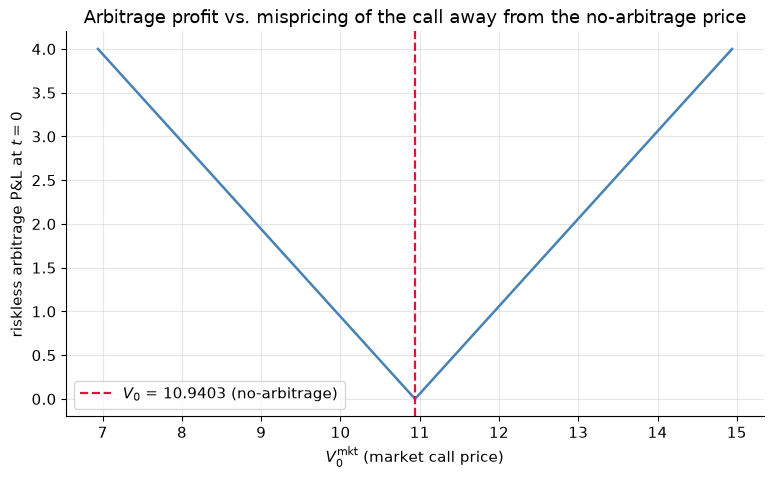

Market call price V0_mkt = 12.9403 (overpriced by 2.0000 vs V0 = 10.9403)

Strategy: sell 1 call @ V0_mkt, buy replicating portfolio (Delta, beta) @ V0_replication
  Cash received at t=0 (riskless):  2.000000
  Net payoff at T, state up:        -7.11e-15  (portfolio covers the call exactly)
  Net payoff at T, state down:      -7.11e-15  (portfolio covers the call exactly)


In [3]:
# Demo 2: sweep of market call price around the no-arbitrage price -> arbitrage P&L
mkt_prices = np.linspace(V0_rn - 4, V0_rn + 4, 41)
riskless_pnl = np.abs(mkt_prices - V0_rn)  # locked-in profit at t=0, same in both states at T

fig, ax = plt.subplots()
ax.plot(mkt_prices, riskless_pnl, color="steelblue", linewidth=1.8)
ax.axvline(V0_rn, color="crimson", linestyle="--", linewidth=1.6, label=fr"$V_0$ = {V0_rn:.4f} (no-arbitrage)")
ax.set_xlabel(r"$V_0^{\mathrm{mkt}}$ (market call price)")
ax.set_ylabel("riskless arbitrage P&L at $t=0$")
ax.set_title("Arbitrage profit vs. mispricing of the call away from the no-arbitrage price")
ax.legend()
plt.show()

# explicit construction for one mispricing: market overprices the call by +2
mispricing = 2.0
V0_mkt = V0_rn + mispricing

# strategy: sell the call, buy the replicating portfolio
cash_at_0 = V0_mkt - V0_replication  # income from selling call minus cost of replicating portfolio
payoff_u = Pi_u - Vu  # portfolio payoff minus call obligation, state up
payoff_d = Pi_d - Vd  # portfolio payoff minus call obligation, state down

print(f"Market call price V0_mkt = {V0_mkt:.4f} (overpriced by {mispricing:.4f} vs V0 = {V0_rn:.4f})\n")
print("Strategy: sell 1 call @ V0_mkt, buy replicating portfolio (Delta, beta) @ V0_replication")
print(f"  Cash received at t=0 (riskless):  {cash_at_0:.6f}")
print(f"  Net payoff at T, state up:        {payoff_u:.2e}  (portfolio covers the call exactly)")
print(f"  Net payoff at T, state down:      {payoff_d:.2e}  (portfolio covers the call exactly)")

La ganancia sin riesgo en $t=0$ crece linealmente con $|V_0^{\text{mkt}}-V_0|$ — es exactamente el tamaño del error de valuación, capturado sin exposición residual porque la cartera replicante cubre al call peso por peso en ambos estados de $T$. En la construcción explícita, el efectivo recibido al vender el call sobrevaluado y comprar la réplica es positivo y determinístico, y el payoff neto en $T$ es cero en ambos estados (hasta precisión de máquina): la definición misma de arbitraje. Esto es la contraparte constructiva de la demostración de la sección 2.2 — cualquier precio de mercado distinto del precio teórico genera una estrategia de este tipo.

## 5. El modelo trinomial: incompletitud y el intervalo de no-arbitraje

### 5.1 Configuración

Ahora $S_T$ puede tomar **tres** valores en $T$: $S_T \in \{uS_0, mS_0, dS_0\}$ con $d < m < u$, mientras que solo tenemos **dos** activos negociados ($S$ y el bono). El sistema de replicación para un derivado con payoff $(V_u,V_m,V_d)$ es
$$
\Delta\, uS_0 + \beta e^{rT} = V_u, \qquad \Delta\, mS_0 + \beta e^{rT} = V_m, \qquad \Delta\, dS_0 + \beta e^{rT} = V_d,
$$
tres ecuaciones en dos incógnitas $(\Delta,\beta)$: el sistema está **sobredeterminado** y, para un payoff genérico, no tiene solución exacta. El mercado trinomial es **incompleto**: no todo derivado es replicable, y por lo tanto no hay un único precio de no-arbitraje — hay, en cambio, un **conjunto** de medidas $\mathbb{Q}=(q_u,q_m,q_d)$ con $q_i>0$, $\sum q_i=1$, que satisfacen la condición de martingala $\mathbb{E}^{\mathbb{Q}}[e^{-rT}S_T]=S_0$, y cada una da un precio de no-arbitraje válido y distinto para el mismo derivado.

### 5.2 El intervalo de precios sin arbitraje vía super/sub-replicación

En lugar de enumerar medidas, acotamos directamente el conjunto de precios consistentes con no-arbitraje resolviendo dos problemas de optimización sobre las **posiciones del portafolio** $(\Delta,\beta)$:

**Sub-replicación (cota inferior).** Buscamos la cartera más cara posible cuyo payoff nunca exceda al del derivado en ningún estado — el mayor precio que un vendedor puede cobrar de forma segura sin poder ser arbitrado:
$$
\text{precio}_{\inf} = \max_{\Delta,\beta}\ \Delta S_0 + \beta \quad \text{s.a.}\quad \Delta\, iS_0 + \beta e^{rT} \leq V_i \ \ \forall i\in\{u,m,d\}.
$$

**Super-replicación (cota superior).** Buscamos la cartera más barata posible cuyo payoff domine al del derivado en todo estado — el costo de la cobertura perfecta de un vendedor que no puede tomar riesgo:
$$
\text{precio}_{\sup} = \min_{\Delta,\beta}\ \Delta S_0 + \beta \quad \text{s.a.}\quad \Delta\, iS_0 + \beta e^{rT} \geq V_i \ \ \forall i\in\{u,m,d\}.
$$

Ambos son programas lineales en las dos variables $(\Delta,\beta)$ con tres restricciones lineales, resolubles a mano por casos o —como hacemos aquí— con `scipy.optimize.linprog` (que minimiza por convención; para el sub-replicante minimizamos $-(\Delta S_0+\beta)$). **Teorema (folklore de no-arbitraje, versión LP).** Cualquier precio $V_0 \in [\text{precio}_{\inf}, \text{precio}_{\sup}]$ es libre de arbitraje, y ningún precio fuera del intervalo lo es: por debajo de $\text{precio}_{\inf}$ comprar el derivado y vender la cartera sub-replicante (óptima) da arbitraje; por encima de $\text{precio}_{\sup}$, vender el derivado y comprar la cartera super-replicante lo da. El intervalo colapsa a un punto exactamente cuando el mercado es completo (caso binomial: dos estados, dos activos, las restricciones se vuelven igualdades).

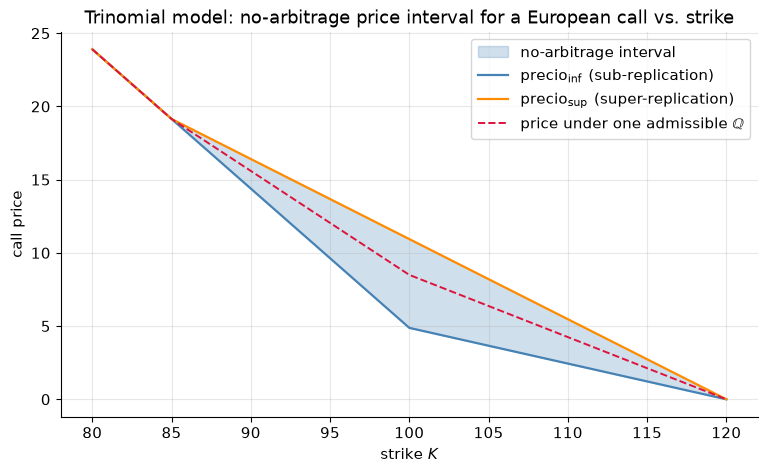

Example (K=100): [4.8771, 10.9403]
q_vec (admissible risk-neutral measure) = [0.44648885 0.3        0.25351115], sum = 1.000000


In [4]:
# Demo 3: trinomial no-arbitrage price interval via linprog, swept over strikes
u_tri, m_tri, d_tri, r_tri, T_tri = 1.2, 1.0, 0.85, 0.05, 1.0
S0_tri = 100.0
states = np.array([u_tri, m_tri, d_tri]) * S0_tri  # S_T in each state
disc = np.exp(-r_tri * T_tri)


def call_payoff(strike, S_T=states):
    return np.maximum(S_T - strike, 0.0)


def price_bounds(V_states, S_T=states, S0=S0_tri, r=r_tri, T=T_tri):
    '''Sub- and super-replication linear programs for a 3-state (trinomial) payoff.

    Decision variables x = (Delta, beta). Portfolio value at t=0 is Delta*S0 + beta.
    Portfolio payoff in state i is Delta*S_T[i] + beta*exp(r*T).
    '''
    disc_factor = np.exp(r * T)
    c0 = np.array([S0, 1.0])  # objective: portfolio value at t=0

    # sub-replication: max Delta*S0+beta s.t. Delta*S_T[i]+beta*e^{rT} <= V_i
    A_sub = np.column_stack([S_T, np.full_like(S_T, disc_factor)])
    res_sub = linprog(c=-c0, A_ub=A_sub, b_ub=V_states, bounds=[(None, None)] * 2, method="highs")
    price_inf = -res_sub.fun

    # super-replication: min Delta*S0+beta s.t. Delta*S_T[i]+beta*e^{rT} >= V_i  <=>  -A x <= -V
    res_sup = linprog(c=c0, A_ub=-A_sub, b_ub=-V_states, bounds=[(None, None)] * 2, method="highs")
    price_sup = res_sup.fun

    return price_inf, price_sup


strikes = np.linspace(80, 120, 25)
lo_bounds, hi_bounds, q_prices = [], [], []

# an admissible risk-neutral measure for the trinomial tree: q . states = S0*e^{rT}, q_m fixed at 0.30
target = np.exp(r_tri * T_tri)
q_m_fixed = 0.30
A_eq = np.array([[u_tri, d_tri], [1.0, 1.0]])
b_eq = np.array([target - q_m_fixed * m_tri, 1.0 - q_m_fixed])
q_u, q_d = np.linalg.solve(A_eq, b_eq)
q_vec = np.array([q_u, q_m_fixed, q_d])
assert np.all(q_vec > 0) and np.all(q_vec < 1), "q_vec must be an admissible probability vector"

for K_i in strikes:
    V_i = call_payoff(K_i)
    lo, hi = price_bounds(V_i)
    lo_bounds.append(lo)
    hi_bounds.append(hi)
    q_prices.append(disc * float(q_vec @ V_i))

lo_bounds, hi_bounds, q_prices = map(np.array, (lo_bounds, hi_bounds, q_prices))

fig, ax = plt.subplots()
ax.fill_between(strikes, lo_bounds, hi_bounds, color="steelblue", alpha=0.25, label="no-arbitrage interval")
ax.plot(strikes, lo_bounds, color="steelblue", linewidth=1.6, label=r"$\mathrm{precio}_{\inf}$ (sub-replication)")
ax.plot(strikes, hi_bounds, color="darkorange", linewidth=1.6, label=r"$\mathrm{precio}_{\sup}$ (super-replication)")
ax.plot(strikes, q_prices, color="crimson", linestyle="--", linewidth=1.4, label=r"price under one admissible $\mathbb{Q}$")
ax.set_xlabel("strike $K$")
ax.set_ylabel("call price")
ax.set_title("Trinomial model: no-arbitrage price interval for a European call vs. strike")
ax.legend()
plt.show()

lo100, hi100 = price_bounds(call_payoff(100.0))
print(f"Example (K=100): [{lo100:.4f}, {hi100:.4f}]")
print(f"q_vec (admissible risk-neutral measure) = {q_vec}, sum = {q_vec.sum():.6f}")

El intervalo $[\text{precio}_{\inf}, \text{precio}_{\sup}]$ tiene ancho positivo para todo strike — la firma numérica de la incompletitud: no hay una cartera de dos activos que replique exactamente el call en tres estados, así que sub- y super-replicación difieren. El precio bajo la medida $\mathbb{Q}$ auxiliar (calibrada para ser una medida martingala admisible, $q_i\in(0,1)$) cae siempre dentro del intervalo, como debe ser: cualquier medida neutral al riesgo admisible da un precio de no-arbitraje válido, y el intervalo es la envolvente de **todos** esos precios sobre todas las medidas admisibles. Nótese que el intervalo se angosta relativo al rango del payoff conforme el strike se aleja del dinero (payoff cada vez más "binomial" en la práctica, dominado por un solo estado), aunque nunca colapsa a un punto salvo en casos degenerados del payoff.

## 6. Validación

Dos asserts, alineados con las dos demostraciones del notebook:

1. **Replicación exacta (binomial).** El payoff del portafolio $(\Delta,\beta)$ de la Demo 1 debe coincidir con el payoff del call en ambos estados con tolerancia absoluta $10^{-12}$ (el sistema $2\times2$ tiene solución exacta en aritmética real; solo queda el redondeo de punto flotante).
2. **Precio dentro del intervalo trinomial.** Para cada strike barrido en la Demo 3, el precio bajo la medida $\mathbb{Q}$ admisible debe estar dentro de $[\text{precio}_{\inf}, \text{precio}_{\sup}]$ (con una tolerancia numérica pequeña para el propio solver de LP).

In [5]:
# Validation 1: exact replication in the binomial model (atol 1e-12)
np.testing.assert_allclose(Pi_u, Vu, atol=1e-12)
np.testing.assert_allclose(Pi_d, Vd, atol=1e-12)
np.testing.assert_allclose(V0_replication, V0_rn, atol=1e-12)
print(f"Replication check: |Pi_u - V_u| = {abs(Pi_u - Vu):.2e}, |Pi_d - V_d| = {abs(Pi_d - Vd):.2e}")
print(f"Pricing check:      |V0_replication - V0_rn| = {abs(V0_replication - V0_rn):.2e}")
print("Validation 1 passed: exact replication and pricing consistency at atol=1e-12.\n")

# Validation 2: risk-neutral price lies within the trinomial no-arbitrage interval, for every swept strike
lp_tol = 1e-6
in_interval = (q_prices >= lo_bounds - lp_tol) & (q_prices <= hi_bounds + lp_tol)
assert np.all(in_interval), "risk-neutral price fell outside the [inf, sup] no-arbitrage interval for some strike"

widths = hi_bounds - lo_bounds
print(f"Checked {len(strikes)} strikes; min interval width = {widths.min():.4f}, max interval width = {widths.max():.4f}")
print(f"All {int(in_interval.sum())}/{len(strikes)} risk-neutral prices fall within [precio_inf, precio_sup].")
print("Validation 2 passed: risk-neutral price within trinomial no-arbitrage interval for all swept strikes.")

Replication check: |Pi_u - V_u| = 7.11e-15, |Pi_d - V_d| = 7.11e-15
Pricing check:      |V0_replication - V0_rn| = 1.24e-14
Validation 1 passed: exact replication and pricing consistency at atol=1e-12.

Checked 25 strikes; min interval width = 0.0000, max interval width = 6.0632
All 25/25 risk-neutral prices fall within [precio_inf, precio_sup].
Validation 2 passed: risk-neutral price within trinomial no-arbitrage interval for all swept strikes.


## Referencias

- Shreve, S. (2004). *Stochastic Calculus for Finance I: The Binomial Asset Pricing Model*, cap. 1.
- Pliska, S. (1997). *Introduction to Mathematical Finance: Discrete Time Models*. Blackwell.